## 一、PCA核心背景与信息压缩
### 1. 为什么需要PCA？
- **问题**：高维数据中变量间常存在**强相关性**（共线性），直接建模会导致计算复杂、模型过拟合，且结论孤立。
- **目标**：**降维**，用尽可能少的新变量（主成分）代替原始变量，同时**最大程度保留原始信息**。
- **适用前提**：变量间**相关性强**（共线性明显）。
  -  若变量独立/相关性极低，则无需PCA，压缩会丢失信息。
  -  分类变量不可直接PCA（需先做WOE转换）。

### 2. 信息压缩的两种方式
| 方式 | 原理 | 缺点 |
| :--- | :--- | :--- |
| **特征消除** | 删去无关/共线性变量（如卡方检验、手动删） | 极易丢失关键信息 |
| **特征提取**（PCA核心） | 组合原始变量创建新变量（主成分），**正交且不相关** | 主成分无实际业务含义，需结合业务解释 |


## 二、主成分分析原理
### 1. 核心几何直观：坐标轴旋转
- **原始空间**：变量间相关 → 散点图呈**椭圆/椭球**分布。
- **PCA操作**：**旋转坐标轴**，找到数据方差最大的方向（第一主成分）和次大方向（第二主成分）。
  - **长轴**：代表信息最丰富的方向。
  - **短轴**：信息可忽略。
- **压缩**：剔除短轴方向，仅保留长轴，实现降维。

### 2. 主成分的含义
- **主成分 $P_1, P_2, \dots$**：由原始变量（如品格、能力、资本）**线性组合**而成的新变量。
  - 公式示例：
    $$
    P_1 = 0.41X_1 + 0.47X_2 + \dots + 0.42X_5
    $$
    $$
    P_2 = 0.83X_1 - 0.27X_2 + \dots - 0.27X_5
    $$
  - **系数解读**：系数绝对值表示该变量对主成分的**贡献权重**（正负号仅代表方向，不影响大小）。

### 3. 如何确定主成分个数 \(k\)？
- **核心准则**：**累积解释方差**（累计贡献率）。
  - 累积解释方差 = 前 $k$ 个主成分方差之和 / 总方差。
  - **行业标准**：累积解释方差达到 **80% ~ 90%** 即可。
  - 实践建议：通常压缩成 **2 ~ 3个** 主成分最合适。


# 二、主成分分析原理
### 1. 核心几何直观：坐标轴旋转
- **原始空间**：变量间相关 → 散点图呈**椭圆/椭球**分布。
- **PCA操作**：**旋转坐标轴**，找到数据方差最大的方向（第一主成分）和次大方向（第二主成分）。
  - **长轴**：代表信息最丰富的方向。
  - **短轴**：信息可忽略。
- **压缩**：剔除短轴方向，仅保留长轴，实现降维。

### 2. 主成分的含义
- **主成分 $P_1, P_2, \dots$**：由原始变量（如品格、能力、资本）**线性组合**而成的新变量。
  - 公式示例：
    $$
    P_1 = 0.41X_1 + 0.47X_2 + \dots + 0.42X_5
    $$
    $$
    P_2 = 0.83X_1 - 0.27X_2 + \dots - 0.27X_5
    $$
  - **系数解读**：系数绝对值表示该变量对主成分的**贡献权重**（正负号仅代表方向，不影响大小）。

### 3. 如何确定主成分个数 $k$？
- **核心准则**：**累积解释方差**（累计贡献率）。
  - 累积解释方差 = 前 $k$ 个主成分方差之和 / 总方差。
  - **行业标准**：累积解释方差达到 **80% ~ 90%** 即可。
  - 实践建议：通常压缩成 **2 ~ 3个** 主成分最合适。

---

## 三、Python实现PCA（信贷评级案例）
### 1. 业务背景与数据
- **案例**：银行客户信贷评级（5C指标：品格、能力、资本、担保、环境）。
- **数据**：`loan_apply.csv`，包含ID和5个评分列。

### 2.python实现

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from patsy.state import scale

plt.style.use('ggplot')
plt.rc('font', **{'family':'Microsoft YaHei,SimHei'})
# 设置中文字体的支持

df = pd.read_csv('loan_apply.csv')
df

,ID,品格,能力,资本,担保,环境
0,1,76.5,81.5,76.0,75.8,71.7
1,2,70.6,73.0,67.6,68.1,78.5
2,3,90.7,87.3,91.0,81.5,80.0
3,4,77.5,73.6,70.9,69.8,74.8
4,5,85.6,68.5,70.0,62.2,76.5
5,6,85.0,79.2,80.3,84.4,76.5
6,7,94.0,94.0,87.5,89.5,92.0
7,8,84.6,66.9,68.8,64.8,66.4
8,9,57.7,60.4,57.4,60.8,65.0
9,10,70.0,69.2,71.7,64.9,68.9


<Axes: >

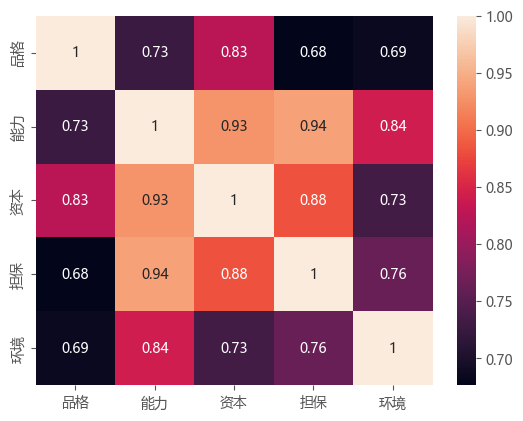

In [5]:
# 确界想关系是的矩阵，证明做主成分分析的必要性
## 丢弃无用的ID列
data = df.drop(columns='ID')

import seaborn as sns
sns.heatmap(data.corr(),annot=True)


变量之间的相关性都比较高，几乎都大于0.7，所以很有必要做PCA

### 3.标准化与PCA建模

各主成分解释方差比例: [0.84223701 0.07667191 0.0594929  0.01591189 0.00568629]
累积解释方差: [0.84223701 0.91890891 0.97840182 0.99431371 1.        ]


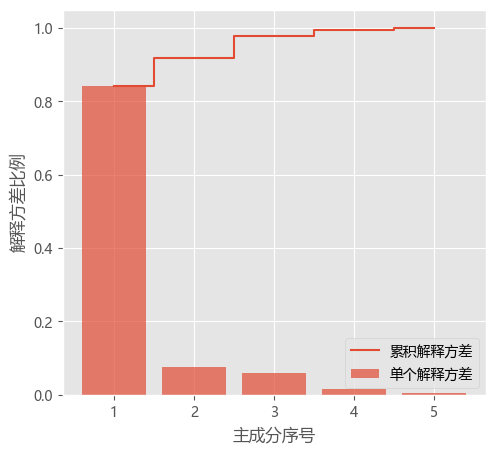

In [11]:
from sklearn.decomposition import PCA

#  数据标准化（PCA对量纲敏感，必须标准化）
data_scaled = scale(data)  # 转化为Z分数

#  拟合PCA（先保留所有成分观察方差）
pca = PCA(n_components=None)  # None = 与变量个数相同(5个)
pca_result = pca.fit_transform(data_scaled)

#  查看累积解释方差
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print("各主成分解释方差比例:", explained_variance)
print("累积解释方差:", cumulative_variance)

# 可视化方差贡献
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.bar(range(1, 6), explained_variance, alpha=0.7, label='单个解释方差')
plt.step(range(1, 6), cumulative_variance, where='mid', label='累积解释方差')
plt.xlabel('主成分序号')
plt.ylabel('解释方差比例')
plt.legend()
plt.grid(True)

### 4.确定最佳维度与降维

In [17]:

###  确定最佳维度与降维
# 选择累积解释方差 > 0.85 的维度
k = np.argmax(cumulative_variance >= 0.85) + 1  # 结果通常为1或2
print(f"建议选择的主成分个数: {k}")

# 重新建模，降维到k个主成分
pca_final = PCA(n_components=k)
final_data = pca_final.fit_transform(data_scaled)
feature_names = df.drop(columns='ID').columns

# 查看主成分权重（系数）
pca_df = pd.DataFrame(pca_final.components_.T,
                      index=feature_names,
                      columns=[f'PC{i+1}' for i in range(k)])
print("主成分权重矩阵:\n", pca_df)


建议选择的主成分个数: 2
主成分权重矩阵:
          PC1       PC2
品格  0.413490  0.834892
能力  0.472893 -0.277802
资本  0.465599  0.143568
担保  0.454653 -0.362100
环境  0.426504 -0.272129


### 5. 业务应用：客户信用打分

In [18]:

# 将降维后的数据与原数据拼接
df['PCA_score'] = final_data[:, 0]  # 通常取第一主成分(PC1)作为综合得分

# 按照综合得分降序排列（风险从低到高）
result = df.sort_values(by='PCA_score', ascending=False)
print("客户信贷评级结果:\n", result)

客户信贷评级结果:
    ID    品格    能力    资本    担保    环境  PCA_score
6   7  94.0  94.0  87.5  89.5  92.0   3.960102
2   3  90.7  87.3  91.0  81.5  80.0   2.603684
5   6  85.0  79.2  80.3  84.4  76.5   1.389937
0   1  76.5  81.5  76.0  75.8  71.7   0.267437
3   4  77.5  73.6  70.9  69.8  74.8  -0.440204
4   5  85.6  68.5  70.0  62.2  76.5  -0.678219
1   2  70.6  73.0  67.6  68.1  78.5  -0.775172
7   8  84.6  66.9  68.8  64.8  66.4  -1.310850
9  10  70.0  69.2  71.7  64.9  68.9  -1.486076
8   9  57.7  60.4  57.4  60.8  65.0  -3.530640



## 四、结果分析与业务解读
### 1. 模型结果解读
- **最佳维度**：本例中仅需 **1个主成分** 即可解释约84%的原始信息。
- **主成分权重**：
  - 第一主成分（PC1）中，**能力、资本、担保** 的权重较大，说明这三个指标是决定客户信用的核心因素。
  - 第二主成分（PC2）权重偏向“品格”，可作为辅助分析。

### 2. 业务决策建议
| 客户ID | PCA得分 | 风险等级 | 运营策略 |
| :--- | :--- | :--- | :--- |
| 7号 | 3.96 | **最低风险** | 重点高价值客户，可提供低息贷款 |
| 2号 | 2.60 | 低风险 | 正常审批，适度优惠 |
| 9号 | -3.53 | **最高风险** | 严格风控，拒绝放贷或要求强抵押 |

### 3. 核心警示
- **黑盒问题**：PCA生成的主成分**没有实际业务语义**。
  - 变量少（5个）时，尚可结合业务解释。
  - 变量多（上百个）时，无法解释，**盲目压缩无意义**。
- **操作建议**：PCA降维后，必须结合**业务需求**（如信贷评级）进行校验，不能只看算法指标。

---


## 五、PCA实战避坑指南（关键注意事项）
1. **必须标准化**：PCA对量纲极度敏感（如身高1.78米与178厘米会完全不同）。
    - 解决：使用 `scale()` 或 `StandardScaler`。
2. **测试集不可泄露**：PCA的参数（均值、标准差、特征向量）必须**仅从训练集计算**，然后应用于测试集。
3. **评估指标**：永远看**累积解释方差**，不要盲目追求维度越低越好。
4. **业务校验**：降维完成后，务必对比原始变量分布，确保没有丢失核心业务特征。

---


### 总结：PCA全流程速记
1. **必要性**：变量相关性高 → 做PCA。
2. **预处理**：标准化处理。
3. **建模**：计算协方差矩阵 → 求特征值/特征向量。
4. **选k**：累积解释方差达85%左右。
5. **应用**：得到主成分得分，用于降维、可视化、打分（如信贷评级）。